# OAI-ZIB Femur Processing (Classification Masks)

This notebook processes **10 random** OAI-ZIB classification masks to extract the femur (label `1`), generate meshes **using the same minimal pipeline as ADNI**, and compare segmentation volumes with mesh volumes.

## 1. Setup and Data Discovery
We use classification segmentation masks from: `/home/jakaria/OAI-ZIB/classification/segmentation_masks`.
Label convention (classification masks):
- `0` background
- `1` femoral bone
- `2` tibial bone


In [2]:
import os
import random
import numpy as np
import pandas as pd
import SimpleITK as sitk
import shapeworks as sw
import trimesh
import tempfile
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from contextlib import redirect_stdout, redirect_stderr, contextmanager, ExitStack

@contextmanager
def suppress_stdout(out=True, err=False):
    with ExitStack() as stack:
        with open(os.devnull, 'w') as null:
            if out:
                stack.enter_context(redirect_stdout(null))
            if err:
                stack.enter_context(redirect_stderr(null))
            yield


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
# Paths
segmentation_dir = '/home/jakaria/OAI-ZIB/classification/segmentation_masks'
output_dir = '/home/jakaria/OAI-ZIB/classification/femur_processed_10'
os.makedirs(output_dir, exist_ok=True)

mhd_files = sorted(glob(os.path.join(segmentation_dir, '*.dmhd')))
print(f'Total .mhd masks found: {len(mhd_files)}')
print('First 5 files:')
for f in mhd_files[:5]:
    print('  ', f)

# Random 10 samples (reproducible)
random.seed(42)
n_samples = min(10, len(mhd_files))
sample_files = random.sample(mhd_files, n_samples)
print(f'Selected {len(sample_files)} random samples')
for f in sample_files:
    print('  ', os.path.basename(f))


Total .mhd masks found: 116
First 5 files:
   /home/jakaria/OAI-ZIB/classification/segmentation_masks/9008561.segmentation_masks.mhd
   /home/jakaria/OAI-ZIB/classification/segmentation_masks/9013798.segmentation_masks.mhd
   /home/jakaria/OAI-ZIB/classification/segmentation_masks/9017909.segmentation_masks.mhd
   /home/jakaria/OAI-ZIB/classification/segmentation_masks/9036770.segmentation_masks.mhd
   /home/jakaria/OAI-ZIB/classification/segmentation_masks/9036948.segmentation_masks.mhd
Selected 10 random samples
   9604541.segmentation_masks.mhd
   9184495.segmentation_masks.mhd
   9036770.segmentation_masks.mhd
   9700341.segmentation_masks.mhd
   9341699.segmentation_masks.mhd
   9331053.segmentation_masks.mhd
   9301332.segmentation_masks.mhd
   9211049.segmentation_masks.mhd
   9171766.segmentation_masks.mhd
   9645577.segmentation_masks.mhd


## 2. Helper Functions
We extract femur (label `1`) and compute:
- Segmentation volume from voxels
- Physical max dimension (for global scale)
- Mesh generation using **ADNI minimal pipeline**: `binarize → pad → toMesh(0.5) → center → volume correction → global scale`


In [31]:
def read_mhd(mhd_path):
    itk_img = sitk.ReadImage(mhd_path)
    arr = sitk.GetArrayFromImage(itk_img)
    return itk_img, arr

def extract_femur_mask(seg_array, label=1):
    return (seg_array == label).astype(np.uint8)

def compute_seg_volume_mm3(mask_array, spacing_xyz):
    voxel_volume = spacing_xyz[0] * spacing_xyz[1] * spacing_xyz[2]
    voxel_count = int(mask_array.sum())
    return voxel_count * voxel_volume

def compute_max_dimension_mm(mask_array, spacing_xyz):
    coords = np.where(mask_array > 0)
    if len(coords[0]) == 0:
        return None
    # coords: (z, y, x); spacing: (x, y, z)
    z_min, z_max = coords[0].min(), coords[0].max()
    y_min, y_max = coords[1].min(), coords[1].max()
    x_min, x_max = coords[2].min(), coords[2].max()
    extent_x = (x_max - x_min) * spacing_xyz[0]
    extent_y = (y_max - y_min) * spacing_xyz[1]
    extent_z = (z_max - z_min) * spacing_xyz[2]
    return max(extent_x, extent_y, extent_z)

def write_binary_mhd(mask_array, reference_itk, out_path):
    itk_mask = sitk.GetImageFromArray(mask_array)
    itk_mask.SetSpacing(reference_itk.GetSpacing())
    itk_mask.SetOrigin(reference_itk.GetOrigin())
    itk_mask.SetDirection(reference_itk.GetDirection())
    sitk.WriteImage(itk_mask, out_path)
    return out_path

def load_trimesh_mesh(mesh_path):
    mesh = trimesh.load(mesh_path)
    if isinstance(mesh, trimesh.Scene):
        mesh = trimesh.util.concatenate(mesh.dump())
    return mesh

def repair_trimesh(mesh):
    # Basic cleanup + hole filling to enforce watertightness
    mesh.remove_duplicate_faces()
    mesh.remove_degenerate_faces()
    mesh.remove_unreferenced_vertices()
    mesh.merge_vertices()
    trimesh.repair.fill_holes(mesh)
    trimesh.repair.fix_inversion(mesh)
    trimesh.repair.fix_normals(mesh)
    return mesh

def trimesh_volume(mesh_path):
    try:
        mesh = load_trimesh_mesh(mesh_path)
        return float(mesh.volume)
    except Exception as e:
        print(f"Volume read error for {mesh_path}: {e}")
        return None


## 3. Global Scale Factor (ADNI-style)
Global scale factor is computed from the **max physical dimension** among the 10 samples.
This matches the ADNI pipeline: `scale = 1 / (max_dim * 1.2)` and `volume_unscale = (1/scale)^3`.

In [32]:
max_dims = []
for f in sample_files:
    itk_img, arr = read_mhd(f)
    femur_mask = extract_femur_mask(arr, label=1)
    md = compute_max_dimension_mm(femur_mask, itk_img.GetSpacing())
    if md is not None:
        max_dims.append(md)

if not max_dims:
    raise RuntimeError('No femur voxels found in the selected samples.')

global_scale = 1.0 / (max(max_dims) * 1.2)
volume_unscale = (1.0 / global_scale) ** 3

print(f'Global scale factor: {global_scale:.8f}')
print(f'Max dimension: {max(max_dims):.2f} mm')
print(f'Volume unscale factor: {volume_unscale:.6e}')


Global scale factor: 0.00859292
Max dimension: 96.98 mm
Volume unscale factor: 1.576079e+06


## 4. Femur Mesh Generation (ADNI Minimal Pipeline)
Pipeline (minimal, no smoothing):
1. `binarize(0)`
2. `pad(5, 0)`
3. `toMesh(0.5)`
4. center at origin
5. volume correction to match segmentation volume
6. global scale


In [33]:
binary_dir = os.path.join(output_dir, 'binary_masks')
mesh_dir = os.path.join(output_dir, 'meshes_minimal')
os.makedirs(binary_dir, exist_ok=True)
os.makedirs(mesh_dir, exist_ok=True)

def process_femur_case(mhd_path, global_scale):
    basename = os.path.basename(mhd_path).replace('.segmentation_masks.mhd', '').replace('.mhd', '')
    itk_img, arr = read_mhd(mhd_path)
    spacing = itk_img.GetSpacing()

    femur_mask = extract_femur_mask(arr, label=1)
    if femur_mask.sum() == 0:
        return None

    # Save binary femur mask to disk for ShapeWorks
    femur_mhd = os.path.join(binary_dir, f"{basename}_femur.mhd")
    write_binary_mhd(femur_mask, itk_img, femur_mhd)

    # Ground-truth volume from segmentation
    seg_volume_mm3 = compute_seg_volume_mm3(femur_mask, spacing)

    # Mesh generation (ADNI minimal pipeline)
    mesh_path = os.path.join(mesh_dir, f"{basename}_femur.ply")

    with suppress_stdout():
        shape_seg = sw.Image(femur_mhd)
        shape_seg.binarize(0)
        shape_seg.pad(5, 0)
        mesh_shape = shape_seg.toMesh(0.5)

        # Center mesh
        center = mesh_shape.center()
        mesh_shape.translate(list(-center))

        # Write temp mesh and repair if needed
        tmp = tempfile.NamedTemporaryFile(suffix='.ply', delete=False)
        tmp_path = tmp.name
        tmp.close()
        mesh_shape.write(tmp_path)

    mesh_tmp = load_trimesh_mesh(tmp_path)
    os.unlink(tmp_path)

    was_watertight = bool(mesh_tmp.is_watertight)
    if not was_watertight:
        mesh_tmp = repair_trimesh(mesh_tmp)

    is_watertight = bool(mesh_tmp.is_watertight)
    is_volume = bool(mesh_tmp.is_volume)

    mesh_volume_mm3 = float(mesh_tmp.volume)
    if mesh_volume_mm3 <= 0:
        return None

    # Volume correction to match segmentation volume
    vol_correction = (seg_volume_mm3 / mesh_volume_mm3) ** (1.0 / 3.0)
    mesh_tmp.apply_scale(vol_correction)

    # Apply global scale
    mesh_tmp.apply_scale(global_scale)

    # Save final mesh
    mesh_tmp.export(mesh_path)

    # Final mesh volume (scaled)
    mesh_volume_scaled = float(mesh_tmp.volume)
    mesh_volume_unscaled = mesh_volume_scaled * volume_unscale if mesh_volume_scaled is not None else None

    return {
        'id': basename,
        'mask_path': femur_mhd,
        'mesh_path': mesh_path,
        'seg_volume_mm3': seg_volume_mm3,
        'mesh_volume_scaled': mesh_volume_scaled,
        'mesh_volume_unscaled_mm3': mesh_volume_unscaled,
        'volume_correction': vol_correction,
        'was_watertight': was_watertight,
        'is_watertight': is_watertight,
        'is_volume': is_volume,
    }


In [34]:
records = []
for f in tqdm(sample_files, desc='Processing femur meshes'):
    rec = process_femur_case(f, global_scale)
    if rec:
        records.append(rec)

df = pd.DataFrame(records)
print(df[['id', 'seg_volume_mm3', 'mesh_volume_unscaled_mm3', 'volume_correction']].head())

csv_path = os.path.join(output_dir, 'femur_10_volume_summary.csv')
df.to_csv(csv_path, index=False)
print(f'Saved summary to: {csv_path}')


Processing femur meshes: 100%|██████████| 10/10 [00:31<00:00,  3.15s/it]

        id  seg_volume_mm3  mesh_volume_unscaled_mm3  volume_correction
0  9604541   165053.982915             165053.982915           1.000043
1  9184495   149260.592652             149260.592652           1.000046
2  9036770   157268.749484             157268.749484           1.000042
3  9700341   142059.186035             142059.186035           1.000049
4  9341699   155260.505430             155260.505430           1.000044
Saved summary to: /home/jakaria/OAI-ZIB/classification/femur_processed_10/femur_10_volume_summary.csv


## 5. Volume Comparison
Compare segmentation volume vs. mesh volume (unscaled back to mm³).

In [35]:
if len(df) > 0:
    df['abs_error_mm3'] = (df['mesh_volume_unscaled_mm3'] - df['seg_volume_mm3']).abs()
    df['error_pct'] = df['abs_error_mm3'] / df['seg_volume_mm3'] * 100

    print('Mean absolute error (mm³):', df['abs_error_mm3'].mean())
    print('Mean percent error (%):', df['error_pct'].mean())

    display_cols = ['id', 'seg_volume_mm3', 'mesh_volume_unscaled_mm3', 'error_pct',
                    'was_watertight', 'is_watertight', 'is_volume']
    display(df[display_cols].sort_values('error_pct').head(10))

    print('Watertight meshes (before repair):', int(df['was_watertight'].sum()), '/', len(df))
    print('Watertight meshes (after repair):', int(df['is_watertight'].sum()), '/', len(df))
    print('Closed volume meshes:', int(df['is_volume'].sum()), '/', len(df))
else:
    print('No valid femur meshes processed.')


Mean absolute error (mm³): 5.238689482212067e-11
Mean percent error (%): 3.4289736964596126e-14


,id,seg_volume_mm3,mesh_volume_unscaled_mm3,error_pct,was_watertight,is_watertight,is_volume
9,9645577,177289.382573,177289.382573,1.641600e-14,True,True,True
2,9036770,157268.749484,157268.749484,1.850579e-14,True,True,True
8,9171766,149387.011659,149387.011659,1.948217e-14,True,True,True
3,9700341,142059.186035,142059.186035,2.048712e-14,True,True,True
0,9604541,165053.982915,165053.982915,3.526583e-14,True,True,True
6,9301332,163833.047914,163833.047914,3.552864e-14,True,True,True
7,9211049,151469.348923,151469.348923,3.842867e-14,True,True,True
5,9331053,132135.039132,132135.039132,4.405165e-14,True,True,True
4,9341699,155260.505430,155260.505430,5.623548e-14,True,True,True
1,9184495,149260.592652,149260.592652,5.849601e-14,True,True,True


Watertight meshes (before repair): 10 / 10
Watertight meshes (after repair): 10 / 10
Closed volume meshes: 10 / 10


In [36]:
sample = sample_files[0]
itk_img, arr = read_mhd(sample)
spacing = itk_img.GetSpacing()
mask = extract_femur_mask(arr, label=1)

seg_vol = compute_seg_volume_mm3(mask, spacing)
print("Spacing (mm):", spacing)
print("Seg volume (mm³):", seg_vol)

row = df.iloc[0]
print("Mesh volume unscaled (mm³):", row["mesh_volume_unscaled_mm3"])
print("Abs error:", abs(row["mesh_volume_unscaled_mm3"] - seg_vol))


Spacing (mm): (0.700001, 0.364583, 0.364583)
Seg volume (mm³): 165053.98291471918
Mesh volume unscaled (mm³): 165053.98291471924
Abs error: 5.820766091346741e-11


## 6. Visualization (Meshes)
Show a few femur meshes to confirm geometry.

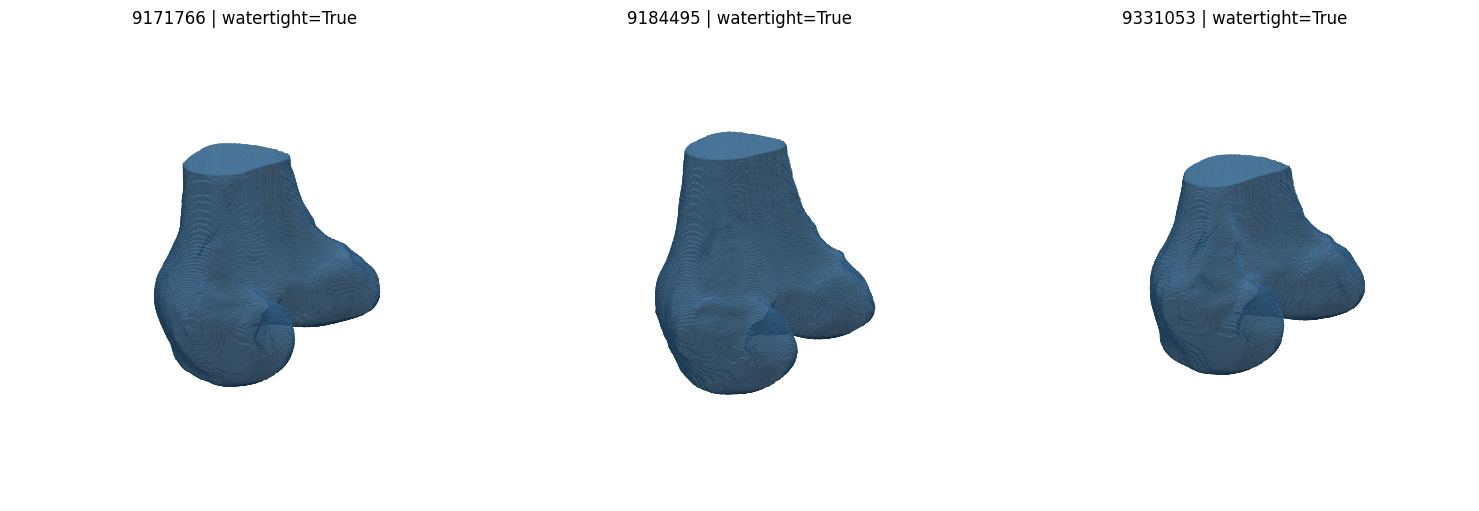

In [37]:
def plot_mesh(ax, mesh, color='steelblue'):
    vertices = mesh.vertices
    faces = mesh.faces

    ax.plot_trisurf(
        vertices[:, 0], vertices[:, 1], vertices[:, 2],
        triangles=faces,
        color=color,
        linewidth=0.0,
        edgecolor='none',
        alpha=1.0,
        shade=True
    )
    ax.set_axis_off()

# Visualize up to 3 meshes with shared axis limits
vis_n = min(3, len(df))
if vis_n > 0:
    vis_samples = df.sample(vis_n, random_state=42)
    meshes = [load_trimesh_mesh(row['mesh_path']) for _, row in vis_samples.iterrows()]

    mins = np.min([m.bounds[0] for m in meshes], axis=0)
    maxs = np.max([m.bounds[1] for m in meshes], axis=0)

    # Make cubic bounds to preserve aspect ratio
    center = (mins + maxs) / 2.0
    max_range = (maxs - mins).max() / 2.0

    fig = plt.figure(figsize=(5 * vis_n, 5), facecolor='white')
    for i, ((_, row), mesh) in enumerate(zip(vis_samples.iterrows(), meshes), start=1):
        ax = fig.add_subplot(1, vis_n, i, projection='3d')
        ax.set_facecolor('white')
        plot_mesh(ax, mesh, color='steelblue')
        ax.set_xlim(center[0] - max_range, center[0] + max_range)
        ax.set_ylim(center[1] - max_range, center[1] + max_range)
        ax.set_zlim(center[2] - max_range, center[2] + max_range)
        ax.set_title(f"{row['id']} | watertight={row['is_watertight']}")
        ax.view_init(elev=20, azim=35)

    plt.tight_layout()
    plt.show()
else:
    print('No meshes available for visualization.')


In [39]:
# Disease labels (pasted)
labels_tsv = '''patient_id	label	label_name	kl_grade
9008561	0	healthy	0-1
9013798	0	healthy	0-1
9017909	0	healthy	0-1
9036770	0	healthy	0-1
9036948	0	healthy	0-1
9039744	0	healthy	0-1
9089627	0	healthy	0-1
9108461	0	healthy	0-1
9116298	0	healthy	0-1
9120941	0	healthy	0-1
9132486	0	healthy	0-1
9141244	0	healthy	0-1
9153509	0	healthy	0-1
9171766	0	healthy	0-1
9184495	0	healthy	0-1
9189553	0	healthy	0-1
9207016	0	healthy	0-1
9211049	0	healthy	0-1
9245519	0	healthy	0-1
9246518	1	diseased	4
9256759	1	diseased	4
9258563	0	healthy	0-1
9263504	1	diseased	4
9266394	1	diseased	4
9267719	1	diseased	4
9271965	1	diseased	4
9284505	1	diseased	4
9287216	1	diseased	4
9301332	1	diseased	4
9304351	0	healthy	0-1
9326657	1	diseased	4
9331053	0	healthy	0-1
9331465	1	diseased	4
9333574	0	healthy	0-1
9340139	1	diseased	4
9341699	0	healthy	0-1
9341903	0	healthy	0-1
9349261	1	diseased	4
9355112	0	healthy	0-1
9364366	1	diseased	4
9365968	1	diseased	4
9375317	1	diseased	4
9379276	1	diseased	4
9383004	0	healthy	0-1
9389580	1	diseased	4
9391061	1	diseased	4
9391372	0	healthy	0-1
9391984	1	diseased	4
9393987	1	diseased	4
9394136	0	healthy	0-1
9397088	0	healthy	0-1
9397976	0	healthy	0-1
9413071	1	diseased	4
9414291	1	diseased	4
9421492	1	diseased	4
9422381	1	diseased	4
9430102	1	diseased	4
9433408	0	healthy	0-1
9439428	1	diseased	4
9440417	0	healthy	0-1
9457359	1	diseased	4
9460287	0	healthy	0-1
9467278	1	diseased	4
9469318	1	diseased	4
9470313	1	diseased	4
9474901	0	healthy	0-1
9475286	1	diseased	4
9477175	1	diseased	4
9477358	1	diseased	4
9486748	0	healthy	0-1
9488834	0	healthy	0-1
9501871	0	healthy	0-1
9504627	0	healthy	0-1
9508335	1	diseased	4
9510418	0	healthy	0-1
9517311	1	diseased	4
9517914	0	healthy	0-1
9557454	1	diseased	4
9568504	1	diseased	4
9582487	0	healthy	0-1
9601162	0	healthy	0-1
9604541	1	diseased	4
9617689	0	healthy	0-1
9631713	1	diseased	4
9638953	1	diseased	4
9642550	1	diseased	4
9645577	0	healthy	0-1
9655592	0	healthy	0-1
9660708	1	diseased	4
9672573	1	diseased	4
9680800	1	diseased	4
9689922	1	diseased	4
9691663	1	diseased	4
9695135	1	diseased	4
9700341	1	diseased	4
9710479	1	diseased	4
9718992	0	healthy	0-1
9745458	1	diseased	4
9750072	0	healthy	0-1
9750090	1	diseased	4
9760079	1	diseased	4
9781749	1	diseased	4
9854269	0	healthy	0-1
9858216	1	diseased	4
9876530	0	healthy	0-1
9878765	0	healthy	0-1
9879069	0	healthy	0-1
9895555	1	diseased	4
9907090	0	healthy	0-1
9916140	0	healthy	0-1
9933836	1	diseased	4
9943227	1	diseased	4
9967815	0	healthy	0-1
9973322	0	healthy	0-1
9978579	0	healthy	0-1
9988421	0	healthy	0-1
'''

import io
labels_df = pd.read_csv(io.StringIO(labels_tsv), sep='	')
labels_df['patient_id'] = labels_df['patient_id'].astype(str)
print('Total labels:', len(labels_df))
labels_df.head()


Total labels: 116


,patient_id,label,label_name,kl_grade
0,9008561,0,healthy,0-1
1,9013798,0,healthy,0-1
2,9017909,0,healthy,0-1
3,9036770,0,healthy,0-1
4,9036948,0,healthy,0-1


## 7. Random 5 Healthy + 5 Diseased Selection
Match label IDs to available segmentation masks and sample 5 healthy + 5 diseased.


In [40]:
# Map patient_id -> mhd path
mhd_files = sorted(glob(os.path.join(segmentation_dir, '*.mhd')))
mhd_map = {}
for f in mhd_files:
    pid = os.path.basename(f).split('.')[0]
    mhd_map[pid] = f

labels_df['has_mask'] = labels_df['patient_id'].isin(mhd_map)
labels_available = labels_df[labels_df['has_mask']].copy()

healthy_df = labels_available[labels_available['label_name'] == 'healthy']
diseased_df = labels_available[labels_available['label_name'] == 'diseased']

if len(healthy_df) < 5 or len(diseased_df) < 5:
    raise RuntimeError('Not enough healthy/diseased samples with masks to sample 5 each.')

# Reproducible random selection
sample_healthy = healthy_df.sample(5, random_state=42)
sample_diseased = diseased_df.sample(5, random_state=42)

selected_labels = pd.concat([sample_healthy, sample_diseased], ignore_index=True)
selected_labels['mhd_path'] = selected_labels['patient_id'].map(mhd_map)

print('Selected 5 healthy + 5 diseased:')
display(selected_labels[['patient_id', 'label_name', 'kl_grade']])


Selected 5 healthy + 5 diseased:


,patient_id,label_name,kl_grade
0,9008561,healthy,0-1
1,9039744,healthy,0-1
2,9474901,healthy,0-1
3,9171766,healthy,0-1
4,9645577,healthy,0-1
5,9246518,diseased,4
6,9271965,diseased,4
7,9508335,diseased,4
8,9364366,diseased,4
9,9680800,diseased,4


## 8. Process Selected 10 (5 Healthy + 5 Diseased)
Compute a new global scale factor from these 10 cases and process with the same ADNI minimal pipeline.


In [41]:
# Output dirs for label-balanced sample
output_dir_labels = '/home/jakaria/OAI-ZIB/classification/femur_processed_healthy_diseased'
binary_dir = os.path.join(output_dir_labels, 'binary_masks')
mesh_dir = os.path.join(output_dir_labels, 'meshes_minimal')
os.makedirs(binary_dir, exist_ok=True)
os.makedirs(mesh_dir, exist_ok=True)

# Compute global scale from selected cases
max_dims = []
for f in selected_labels['mhd_path']:
    itk_img, arr = read_mhd(f)
    femur_mask = extract_femur_mask(arr, label=1)
    md = compute_max_dimension_mm(femur_mask, itk_img.GetSpacing())
    if md is not None:
        max_dims.append(md)

if not max_dims:
    raise RuntimeError('No femur voxels found in selected samples.')

global_scale = 1.0 / (max(max_dims) * 1.2)
volume_unscale = (1.0 / global_scale) ** 3

print(f'Global scale factor (selected 10): {global_scale:.8f}')
print(f'Max dimension: {max(max_dims):.2f} mm')
print(f'Volume unscale factor: {volume_unscale:.6e}')

# Process selected cases
records_hd = []
for f in tqdm(selected_labels['mhd_path'], desc='Processing healthy+diseased'):
    rec = process_femur_case(f, global_scale)
    if rec:
        records_hd.append(rec)

df_hd = pd.DataFrame(records_hd)

# Attach labels
if len(df_hd) > 0:
    df_hd = df_hd.merge(
        selected_labels[['patient_id', 'label_name', 'label', 'kl_grade']],
        left_on='id', right_on='patient_id', how='left'
    )

print('Processed:', len(df_hd), 'meshes')
df_hd.head()


Global scale factor (selected 10): 0.00956367
Max dimension: 87.14 mm
Volume unscale factor: 1.143212e+06


Processing healthy+diseased: 100%|██████████| 10/10 [00:28<00:00,  2.81s/it]

Processed: 10 meshes


,id,mask_path,mesh_path,seg_volume_mm3,mesh_volume_scaled,mesh_volume_unscaled_mm3,volume_correction,was_watertight,is_watertight,is_volume,patient_id,label_name,label,kl_grade
0,9008561,/home/jakaria/OAI-ZIB/classification/femur_pro...,/home/jakaria/OAI-ZIB/classification/femur_pro...,137234.547776,0.120043,137234.547776,1.000049,True,True,True,9008561,healthy,0,0-1
1,9039744,/home/jakaria/OAI-ZIB/classification/femur_pro...,/home/jakaria/OAI-ZIB/classification/femur_pro...,149865.038069,0.131091,149865.038069,1.000048,True,True,True,9039744,healthy,0,0-1
2,9474901,/home/jakaria/OAI-ZIB/classification/femur_pro...,/home/jakaria/OAI-ZIB/classification/femur_pro...,138334.624842,0.121005,138334.624842,1.000047,True,True,True,9474901,healthy,0,0-1
3,9171766,/home/jakaria/OAI-ZIB/classification/femur_pro...,/home/jakaria/OAI-ZIB/classification/femur_pro...,149387.011659,0.130673,149387.011659,1.000045,True,True,True,9171766,healthy,0,0-1
4,9645577,/home/jakaria/OAI-ZIB/classification/femur_pro...,/home/jakaria/OAI-ZIB/classification/femur_pro...,177289.382573,0.155080,177289.382573,1.000040,True,True,True,9645577,healthy,0,0-1


## 9. Visualization: 3 Healthy + 3 Diseased (Shared Axes)
Show 3 healthy and 3 diseased meshes with shared axis limits so relative size is visible.


In [1]:
if len(df_hd) > 0:
    healthy_vis = df_hd[df_hd['label_name'] == 'healthy'].sample(3, random_state=42)
    diseased_vis = df_hd[df_hd['label_name'] == 'diseased'].sample(3, random_state=42)

    vis_groups = [('healthy', healthy_vis), ('diseased', diseased_vis)]

    all_meshes = []
    for _, group_df in vis_groups:
        for _, row in group_df.iterrows():
            all_meshes.append(load_trimesh_mesh(row['mesh_path']))

    mins = np.min([m.bounds[0] for m in all_meshes], axis=0)
    maxs = np.max([m.bounds[1] for m in all_meshes], axis=0)
    center = (mins + maxs) / 2.0
    max_range = (maxs - mins).max() / 2.0

    fig = plt.figure(figsize=(15, 8), facecolor='white')
    colors = {'healthy': 'seagreen', 'diseased': 'firebrick'}

    for r, (group_name, group_df) in enumerate(vis_groups):
        for c, row in enumerate(group_df.itertuples(), start=1):
            mesh = load_trimesh_mesh(row.mesh_path)
            ax = fig.add_subplot(2, 3, r * 3 + c, projection='3d')
            ax.set_facecolor('white')
            plot_mesh(ax, mesh, color=colors[group_name])
            ax.set_xlim(center[0] - max_range, center[0] + max_range)
            ax.set_ylim(center[1] - max_range, center[1] + max_range)
            ax.set_zlim(center[2] - max_range, center[2] + max_range)
            ax.set_title(f"{row.id} | {group_name}")
            ax.view_init(elev=20, azim=35)

    plt.tight_layout()
    plt.show()
else:
    print('No meshes available for healthy/diseased visualization.')


NameError: name 'df_hd' is not defined

## 10. Labels vs Masks Check + Extra CSV (Requires Confirmation)
Standalone block to validate label coverage for classification masks and (optionally) build `extra.csv` for segmentation masks.


In [6]:
# STEP A: Load detailed labels and keep required fields
from pathlib import Path
import pandas as pd

labels_path = Path('/home/jakaria/OAI-ZIB/classification/labels/detailed_labels.csv')
labels_df = pd.read_csv(labels_path)

# Keep required fields
labels_keep = labels_df[['patient_id', 'kl_grade', 'age', 'gender']].copy()
labels_keep['patient_id'] = labels_keep['patient_id'].astype(str)

# Disease rule: KL 0/1 -> 0, KL 4 -> 1 (drop other grades)
labels_keep = labels_keep[labels_keep['kl_grade'].isin([0, 1, 4])].copy()
labels_keep['disease_diagnosis'] = (labels_keep['kl_grade'] == 4).astype(int)

# Gender mapping (numeric): male=0, female=1 (assuming 1=male, 2=female)
sex_map = {1: 0, 2: 1}
labels_keep['gender'] = labels_keep['gender'].map(sex_map)
labels_keep = labels_keep[labels_keep['gender'].notna()].copy()

# Final columns
labels_keep = labels_keep[['patient_id', 'disease_diagnosis', 'kl_grade', 'gender', 'age']]

print('Detailed labels (after KL filter):', len(labels_keep))
display(labels_keep.head())

# STEP B: Match with classification masks
cls_mask_dir = Path('/home/jakaria/OAI-ZIB/classification/segmentation_masks')
cls_mask_ids = {p.name.split('.')[0] for p in cls_mask_dir.glob('*.mhd')}
label_ids = set(labels_keep['patient_id'])

found_in_cls = sorted(label_ids & cls_mask_ids)
missing_in_cls = sorted(label_ids - cls_mask_ids)

print(f"Classification masks found: {len(found_in_cls)}")
print(f"Missing in classification masks: {len(missing_in_cls)}")

# STEP C: Match missing labels in segmentation masks
seg_mask_dir = Path('/home/jakaria/OAI-ZIB/segmentation/segmentation_masks')
seg_mask_ids = {p.name.split('.')[0] for p in seg_mask_dir.glob('*.mhd')}

found_in_seg = sorted(set(missing_in_cls) & seg_mask_ids)
still_missing = sorted(set(missing_in_cls) - seg_mask_ids)

print(f"Found missing labels in segmentation masks: {len(found_in_seg)}")
print(f"Still missing after both folders: {len(still_missing)}")

# STEP D: Build classification_mask_labels.csv for labels that exist in
# classification masks OR (if missing there) in segmentation masks.
found_any = sorted(set(found_in_cls) | set(found_in_seg))
labels_any = labels_keep[labels_keep['patient_id'].isin(found_any)].copy()

# Ensure unique patient_id
before = len(labels_any)
labels_any = labels_any.drop_duplicates(subset=['patient_id'])
after = len(labels_any)
if after != before:
    print(f"Dropped duplicates: {before - after}")

out_csv = Path('/home/jakaria/OAI-ZIB/classification/classification_mask_labels.csv')
labels_any.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print('Rows saved:', len(labels_any))


Detailed labels (after KL filter): 146


,patient_id,disease_diagnosis,kl_grade,gender,age
0,9256759,1,4.0,1,58
1,9263504,1,4.0,1,49
2,9267719,1,4.0,1,64
3,9284505,1,4.0,1,74
4,9287216,1,4.0,1,69


Classification masks found: 70
Missing in classification masks: 76
Found missing labels in segmentation masks: 76
Still missing after both folders: 0
Saved: /home/jakaria/OAI-ZIB/classification/classification_mask_labels.csv
Rows saved: 146


## 11. Train/Test Combined (Exclude Classification Labels)
Combine train+test, exclude IDs already in `classification_mask_labels.csv`, then keep only IDs with masks in **both** mask folders and KL grade in {0,1,4}.


In [8]:
from pathlib import Path
import pandas as pd

# Load existing classification labels (already processed)
cls_labels_path = Path('/home/jakaria/OAI-ZIB/classification/classification_mask_labels.csv')
cls_labels_df = pd.read_csv(cls_labels_path)
cls_ids = set(cls_labels_df['patient_id'].astype(str))

# Load train/test and combine
train_path = Path('/home/jakaria/OAI-ZIB/subInfo_train.csv')
test_path = Path('/home/jakaria/OAI-ZIB/subInfo_test.csv')
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sub_df = pd.concat([train_df, test_df], ignore_index=True)
sub_df['patient_id'] = sub_df['OAI-SubjectID'].astype(str)

# Exclude IDs already in classification labels
sub_df = sub_df[~sub_df['patient_id'].isin(cls_ids)].copy()

# Keep KL grades 0/1/4 only
sub_df = sub_df[sub_df['KLGrade'].isin([0, 1, 4])].copy()

# Disease mapping: KL 0/1 -> 0, KL 4 -> 1
sub_df['disease_diagnosis'] = (sub_df['KLGrade'] == 4).astype(int)

# Gender mapping (numeric): male=0, female=1 (assuming 1=male, 2=female)
sex_map = {1: 0, 2: 1}
sub_df['gender'] = sub_df['Gender'].map(sex_map)
sub_df = sub_df[sub_df['gender'].notna()].copy()

# Mask availability
cls_mask_dir = Path('/home/jakaria/OAI-ZIB/classification/segmentation_masks')
seg_mask_dir = Path('/home/jakaria/OAI-ZIB/segmentation/segmentation_masks')
cls_mask_ids = {p.name.split('.')[0] for p in cls_mask_dir.glob('*.mhd')}
seg_mask_ids = {p.name.split('.')[0] for p in seg_mask_dir.glob('*.mhd')}

sub_ids = set(sub_df['patient_id'])

in_cls = sub_ids & cls_mask_ids
in_seg = sub_ids & seg_mask_ids

print(f"Remaining after exclusion + KL filter: {len(sub_df)}")
print(f"IDs with classification masks: {len(in_cls)}")
print(f"IDs with segmentation masks: {len(in_seg)}")

# Keep IDs that have segmentation masks (labels + masks)
sub_keep = sub_df[sub_df['patient_id'].isin(in_seg)].copy()

# Final columns
sub_keep = sub_keep[['patient_id', 'disease_diagnosis', 'KLGrade', 'gender', 'Age']].rename(
    columns={'KLGrade': 'kl_grade', 'Age': 'age'}
)

out_csv = Path('/home/jakaria/OAI-ZIB/segmentation/train_test_mask_labels.csv')
sub_keep = sub_keep.drop_duplicates(subset=['patient_id'])
sub_keep.to_csv(out_csv, index=False)

print(f"Saved: {out_csv}")
print('Rows saved:', len(sub_keep))


Remaining after exclusion + KL filter: 88
IDs with classification masks: 0
IDs with segmentation masks: 88
Saved: /home/jakaria/OAI-ZIB/segmentation/train_test_mask_labels.csv
Rows saved: 88


## 12. Merge Classification + Train/Test Labels (No Duplicates)


In [9]:
from pathlib import Path
import pandas as pd

cls_csv = Path('/home/jakaria/OAI-ZIB/classification/classification_mask_labels.csv')
train_test_csv = Path('/home/jakaria/OAI-ZIB/segmentation/train_test_mask_labels.csv')

cls_df = pd.read_csv(cls_csv)
train_test_df = pd.read_csv(train_test_csv)

merged = pd.concat([cls_df, train_test_df], ignore_index=True)

before = len(merged)
merged = merged.drop_duplicates(subset=['patient_id'])
after = len(merged)

print(f"Merged rows: {before}")
print(f"Dropped duplicates: {before - after}")

out_csv = Path('/home/jakaria/OAI-ZIB/merged_mask_labels.csv')
merged.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print('Rows saved:', len(merged))


Merged rows: 234
Dropped duplicates: 0
Saved: /home/jakaria/OAI-ZIB/merged_mask_labels.csv
Rows saved: 234


## 13. Print Merged CSV Contents


In [10]:
from pathlib import Path
import pandas as pd

merged_csv = Path('/home/jakaria/OAI-ZIB/merged_mask_labels.csv')
merged_df = pd.read_csv(merged_csv)

# Print all rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(merged_df.to_string(index=False))


 patient_id  disease_diagnosis  kl_grade  gender  age
    9256759                  1       4.0       1   58
    9263504                  1       4.0       1   49
    9267719                  1       4.0       1   64
    9284505                  1       4.0       1   74
    9287216                  1       4.0       1   69
    9326657                  1       4.0       1   78
    9340139                  1       4.0       1   52
    9365968                  1       4.0       1   66
    9379276                  1       4.0       1   65
    9393987                  1       4.0       1   62
    9413071                  1       4.0       1   45
    9422381                  1       4.0       1   61
    9439428                  1       4.0       1   55
    9457359                  1       4.0       1   63
    9475286                  1       4.0       1   56
    9604541                  1       4.0       1   70
    9638953                  1       4.0       1   70
    9680800                 

## 14. Summary Stats: Sex, Disease, Age


Total rows: 234
Sex counts (0=male, 1=female):
gender
0    121
1    113
Name: count, dtype: int64
Disease counts (0=healthy, 1=diseased):
disease_diagnosis
0    161
1     73
Name: count, dtype: int64
Age summary:
count    234.000000
mean      60.645299
std        9.143012
min       45.000000
25%       53.250000
50%       60.000000
75%       68.750000
max       79.000000
Name: age, dtype: float64


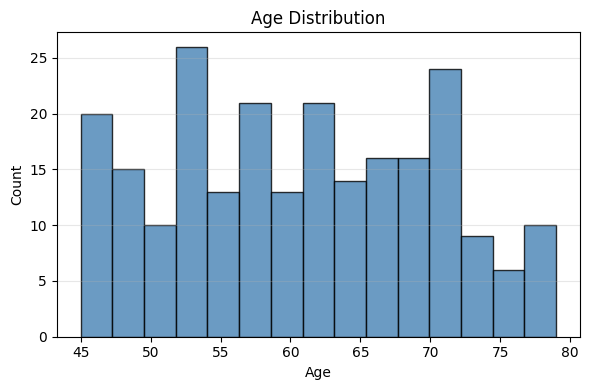

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged_csv = Path('/home/jakaria/OAI-ZIB/merged_mask_labels.csv')
merged_df = pd.read_csv(merged_csv)

# Basic counts
sex_counts = merged_df['gender'].value_counts(dropna=False).sort_index()
disease_counts = merged_df['disease_diagnosis'].value_counts(dropna=False).sort_index()

print('Total rows:', len(merged_df))
print('Sex counts (0=male, 1=female):')
print(sex_counts)
print('Disease counts (0=healthy, 1=diseased):')
print(disease_counts)

# Age distribution
age_series = merged_df['age'].dropna()
print('Age summary:')
print(age_series.describe())

# Plot age histogram
plt.figure(figsize=(6,4))
plt.hist(age_series, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 15. Consistency Check: Merged vs Detailed/Train/Test
Verify that merged labels match source CSVs for overlapping IDs.


In [13]:
from pathlib import Path
import pandas as pd

# Load merged
merged_csv = Path('/home/jakaria/OAI-ZIB/merged_mask_labels.csv')
merged_df = pd.read_csv(merged_csv)
merged_df['patient_id'] = merged_df['patient_id'].astype(str)

# Load detailed labels
labels_path = Path('/home/jakaria/OAI-ZIB/classification/labels/detailed_labels.csv')
labels_df = pd.read_csv(labels_path)
labels_df['patient_id'] = labels_df['patient_id'].astype(str)

# Keep fields + normalize to merged schema
labels_keep = labels_df[['patient_id', 'kl_grade', 'age', 'gender']].copy()
labels_keep = labels_keep[labels_keep['kl_grade'].isin([0, 1, 4])].copy()
labels_keep['disease_diagnosis'] = (labels_keep['kl_grade'] == 4).astype(int)
sex_map = {1: 0, 2: 1}
labels_keep['gender'] = labels_keep['gender'].map(sex_map)
labels_keep = labels_keep[labels_keep['gender'].notna()].copy()
labels_keep = labels_keep[['patient_id', 'disease_diagnosis', 'kl_grade', 'gender', 'age']]

# Load train/test
train_path = Path('/home/jakaria/OAI-ZIB/subInfo_train.csv')
test_path = Path('/home/jakaria/OAI-ZIB/subInfo_test.csv')
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sub_df = pd.concat([train_df, test_df], ignore_index=True)
sub_df['patient_id'] = sub_df['OAI-SubjectID'].astype(str)
sub_df = sub_df[sub_df['KLGrade'].isin([0, 1, 4])].copy()
sub_df['disease_diagnosis'] = (sub_df['KLGrade'] == 4).astype(int)
sex_map = {1: 0, 2: 1}
sub_df['gender'] = sub_df['Gender'].map(sex_map)
sub_df = sub_df[sub_df['gender'].notna()].copy()
sub_keep = sub_df[['patient_id', 'disease_diagnosis', 'KLGrade', 'gender', 'Age']].rename(
    columns={'KLGrade': 'kl_grade', 'Age': 'age'}
)

# Helper for mismatches
FIELDS = ['disease_diagnosis', 'kl_grade', 'gender', 'age']

def mismatch_rows(df, right_suffix):
    cond = False
    for f in FIELDS:
        cond = cond | (df[f"{f}_merged"] != df[f"{f}{right_suffix}"])
    return df[cond]

# Compare merged vs detailed
merge_det = merged_df.merge(labels_keep, on='patient_id', suffixes=('_merged', '_detailed'))
mism_det = mismatch_rows(merge_det, '_detailed')

print('Merged ∩ Detailed:', len(merge_det))
print('Mismatches vs Detailed:', len(mism_det))
if len(mism_det) > 0:
    display(mism_det[['patient_id',
                      'disease_diagnosis_merged', 'disease_diagnosis_detailed',
                      'kl_grade_merged', 'kl_grade_detailed',
                      'gender_merged', 'gender_detailed',
                      'age_merged', 'age_detailed']].head(20))

# Compare merged vs train/test
merge_tt = merged_df.merge(sub_keep, on='patient_id', suffixes=('_merged', '_train_test'))
mism_tt = mismatch_rows(merge_tt, '_train_test')

print('Merged ∩ Train/Test:', len(merge_tt))
print('Mismatches vs Train/Test:', len(mism_tt))
if len(mism_tt) > 0:
    display(mism_tt[['patient_id',
                     'disease_diagnosis_merged', 'disease_diagnosis_train_test',
                     'kl_grade_merged', 'kl_grade_train_test',
                     'gender_merged', 'gender_train_test',
                     'age_merged', 'age_train_test']].head(20))


Merged ∩ Detailed: 146
Mismatches vs Detailed: 0
Merged ∩ Train/Test: 234
Mismatches vs Train/Test: 0
